# EDA enrichi (ADEME × Enedis via IRIS)  


### 01. Chargement & aperçu

In [1]:
import pandas as pd
import numpy as np

path = "../data/df_adem_enedis_iris_69.csv" 
df = pd.read_csv(path)

print("Shape:", df.shape)
df.head(5)

Shape: (358302, 40)


,conso_5_usages_ep,emission_ges_5_usages,nom_commune_ban,type_logement_source,cout_total_5_usages,etiquette_ges,methode_application_dpe,type_energie_principale_chauffage,code_region_ban,conso_refroidissement_ep,...,code_postal_ban,zone_climatique,qualite_isolation_menuiseries,date_reception_dpe,emission_ges_chauffage,codeiris,conso_totale_mwh,conso_moy_site_mwh,conso_moy_commune_mwh,nombre_de_logements
0,16721.9,547.5,ALBIGNY-SUR-SAÔNE,EXISTANT,1238.0,C,DPE APPARTEMENT INDIVIDUEL,ÉLECTRICITÉ,84.0,0.0,...,69250,H1C,INSUFFISANTE,2022-04-02,10.6,690030000,6429.986,2.725961,4.559143,2741.0
1,28697.8,6286.9,ALBIGNY-SUR-SAÔNE,EXISTANT,2174.0,F,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,MOYENNE,2022-06-23,25.4,690030000,6429.986,2.725961,4.559143,2741.0
2,7437.8,1435.8,NEUVILLE-SUR-SAÔNE,EXISTANT,756.7,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-06-07,955.9,691430104,7800.521,2.302478,3.265994,3366.0
3,13047.5,2659.4,NEUVILLE-SUR-SAÔNE,EXISTANT,1175.0,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-01-14,2120.9,691430104,7800.521,2.302478,3.265994,3366.0
4,5616.0,1044.3,ALBIGNY-SUR-SAÔNE,EXISTANT,642.0,C,DPE APPARTEMENT INDIVIDUEL,GAZ NATUREL,84.0,0.0,...,69250,H1C,BONNE,2022-06-14,613.8,690030000,6429.986,2.725961,4.559143,2741.0


In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358302 entries, 0 to 358301
Data columns (total 40 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   conso_5_usages_ep                  358302 non-null  float64
 1   emission_ges_5_usages              358302 non-null  float64
 2   nom_commune_ban                    358302 non-null  object 
 3   type_logement_source               358302 non-null  object 
 4   cout_total_5_usages                358302 non-null  float64
 5   etiquette_ges                      358302 non-null  object 
 6   methode_application_dpe            358302 non-null  object 
 7   type_energie_principale_chauffage  358302 non-null  object 
 8   code_region_ban                    358302 non-null  float64
 9   conso_refroidissement_ep           358302 non-null  float64
 10  qualite_isolation_murs             358302 non-null  object 
 11  coordonnee_cartographique_y_ban    3583

In [72]:
def regrouper_classes_dpe(x):
    if x in ["A", "B"]:
        return "A_B"
    elif x in ["F", "G"]:
        return "F_G"
    else:
        return x

df["etiquette_dpe_grp"] = df["etiquette_dpe"].apply(regrouper_classes_dpe)
df["etiquette_dpe_grp"].value_counts()

etiquette_dpe_grp
C      137782
D      111983
E       60874
F_G     28686
A_B     18977
Name: count, dtype: int64

### 02. Sanity check des colonnes clés

In [73]:
cols_key = [
    "codeiris",
    "conso_5_usages_ep",          # ADEME (kWh/an)
    "etiquette_dpe_grp",
    "surface_habitable_logement",
    "annee_construction",
    "conso_totale_mwh",           # ENEDIS (MWh)
    "conso_moy_site_mwh",         # ENEDIS (MWh/site)
    "conso_moy_commune_mwh",      # ENEDIS (MWh/site communal)
    "nombre_de_logements",
    "nom_commune_ban"
]
[ c for c in cols_key if c not in df.columns ]

[]

In [74]:
# forcer en numériques si besoin
num_cols = ["conso_5_usages_ep","surface_habitable_logement","annee_construction",
            "conso_totale_mwh","conso_moy_site_mwh","conso_moy_commune_mwh","nombre_de_logements"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
conso_5_usages_ep,358302.0,11861.295558,7578.373795,327.700000,6571.900000,10131.700000,15220.400000,93511.800000
surface_habitable_logement,358302.0,62.305836,30.758126,9.000000,42.400000,61.000000,77.000000,582.000000
annee_construction,358302.0,1981.218866,25.305745,1460.000000,1971.000000,1980.000000,1992.000000,2025.000000
conso_totale_mwh,358302.0,24148.546891,16374.614529,156.988000,12111.118000,21566.452000,32007.579000,114948.360000
conso_moy_site_mwh,358302.0,2.748362,0.737178,1.405766,2.300656,2.733488,3.050969,12.134818
conso_moy_commune_mwh,358302.0,3.246239,0.968916,2.568625,2.883820,2.901446,3.129873,9.484000
nombre_de_logements,358302.0,9322.596011,6471.302984,60.000000,5147.000000,7936.000000,11514.000000,39750.000000


####### 03. Contrôles rapides

In [75]:
df["etiquette_dpe"].value_counts(dropna=False)

etiquette_dpe
C    137782
D    111983
E     60874
F     18214
B     15205
G     10472
A      3772
Name: count, dtype: int64

In [77]:
df["etiquette_dpe_grp"].value_counts(dropna=False)

etiquette_dpe_grp
C      137782
D      111983
E       60874
F_G     28686
A_B     18977
Name: count, dtype: int64

In [78]:
df["codeiris"].nunique(), df["codeiris"].isna().sum()

(489, 0)

### 04. Corrélation numérique

In [79]:
# On convertit conso ADEME en MWh pour cohérence d'échelle
df["conso_5_usages_mwh"] = df["conso_5_usages_ep"] / 1000

corr_pearson = df["conso_5_usages_mwh"].corr(df["conso_moy_site_mwh"], method="pearson")
corr_spearman = df["conso_5_usages_mwh"].corr(df["conso_moy_site_mwh"], method="spearman")

print(f"Corrélation de Pearson : {corr_pearson:.3f}")
print(f"Corrélation de Spearman : {corr_spearman:.3f}")

Corrélation de Pearson : 0.153
Corrélation de Spearman : 0.124


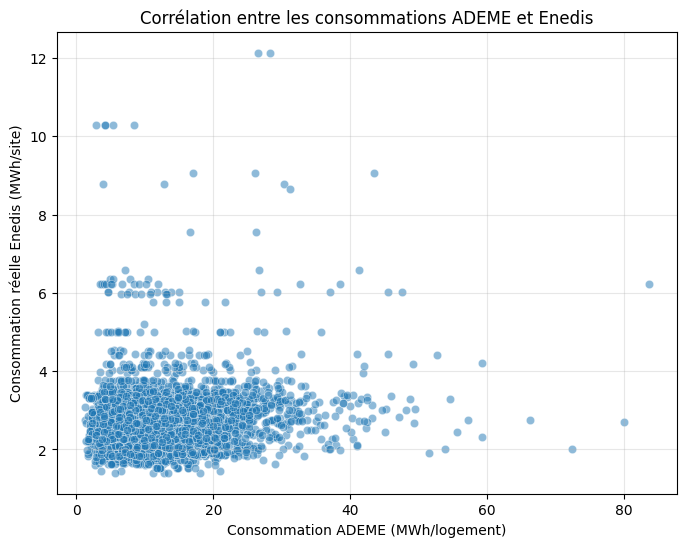

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df.sample(5000, random_state=42),  # pour lisibilité
    x="conso_5_usages_mwh", 
    y="conso_moy_site_mwh",
    alpha=0.5
)
plt.xlabel("Consommation ADEME (MWh/logement)")
plt.ylabel("Consommation réelle Enedis (MWh/site)")
plt.title("Corrélation entre les consommations ADEME et Enedis")
plt.grid(True, alpha=0.3)
plt.show()


### 05. Écart entre consommation réelle (Enedis) et estimée (ADEME) — par IRIS

In [81]:
df_group = (
    df.groupby("codeiris")
    .agg({
        "conso_5_usages_ep": "mean",
        "conso_moy_site_mwh": "mean",
        "nombre_de_logements": "sum",
        "surface_habitable_logement": "mean",
        "annee_construction": "mean",
        "etiquette_dpe_grp": lambda x: x.mode()[0] if len(x.mode()) > 0 else None,
        "nom_commune_ban": lambda x: ", ".join(sorted(x.unique()))
    })
    .reset_index()
    .rename(columns={
        "conso_5_usages_ep": "conso_adem_moyenne_kwh",
        "conso_moy_site_mwh": "conso_enedis_moyenne_mwh"
    })
)

# Recalculer les moyennes MWh ADEME et l’écart
df_group["conso_adem_moyenne_mwh"] = df_group["conso_adem_moyenne_kwh"] / 1000
df_group["ecart_mwh"] = df_group["conso_enedis_moyenne_mwh"] - df_group["conso_adem_moyenne_mwh"]


In [82]:
import geopandas as gpd

# Charger le shapefile IRIS Rhône
gdf_iris = gpd.read_file("../data/IRIS_Rhone/ter_territoire_teriris_ge_latest.shp", encoding="latin1")

# Harmoniser la clé d’identifiant
gdf_iris = gdf_iris.rename(columns={"codeiris": "codeiris"})

# Fusion avec le tableau agrégé df_group
gdf_map = gdf_iris.merge(df_group, on="codeiris", how="left")

print("Taille finale :", gdf_map.shape)
gdf_map.head(3)

Taille finale : (512, 17)


,codeiris,libelle,type,typelibell,commune,insee,gid,geometry,conso_adem_moyenne_kwh,conso_enedis_moyenne_mwh,nombre_de_logements,surface_habitable_logement,annee_construction,etiquette_dpe_grp,nom_commune_ban,conso_adem_moyenne_mwh,ecart_mwh
0,690030000,Albigny-sur-SaÃ´ne,Z,Commune non irisÃ©e,Albigny-sur-SaÃ´ne,69003,1,"POLYGON ((4.81744 45.85602, 4.81762 45.85619, ...",13483.485235,2.725961,1633636.0,79.590101,1983.474832,C,"ALBIGNY SUR SAONE, ALBIGNY-SUR-SA*U00F4NE, ALB...",13.483485,-10.757524
1,690290101,Les GenÃªts-HÃ´pitaux,H,Habitat,Bron,69029,2,"POLYGON ((4.89185 45.73853, 4.89188 45.7391, 4...",15661.212618,2.705359,1630648.0,63.207413,1977.017350,E,BRON,15.661213,-12.955853
2,690290102,Gendarmerie-Garenne,H,Habitat,Bron,69029,3,"POLYGON ((4.90602 45.74374, 4.90615 45.74416, ...",9872.684199,2.497025,5848110.0,66.651050,2005.170166,A_B,BRON,9.872684,-7.375659


In [83]:
gdf_map["ecart_mwh"] = gdf_map["conso_enedis_moyenne_mwh"] - gdf_map["conso_adem_moyenne_mwh"]

# Supprimer les zones sans valeurs
gdf_map = gdf_map.dropna(subset=["ecart_mwh"])

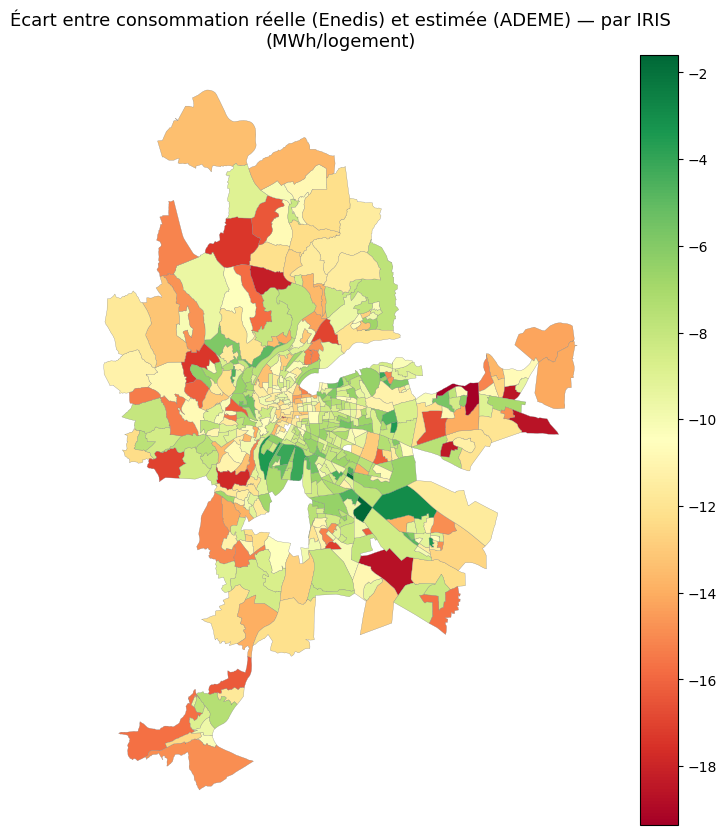

In [84]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf_map.plot(
    column="ecart_mwh",
    cmap="RdYlGn",  # rouge = surestimation ADEME, vert = sous-estimation
    linewidth=0.2,
    edgecolor="gray",
    legend=True,
    ax=ax
)
plt.title("Écart entre consommation réelle (Enedis) et estimée (ADEME) — par IRIS\n(MWh/logement)", fontsize=13)
plt.axis("off")
plt.show()


In [85]:
import plotly.express as px

# Création de la carte interactive
fig = px.choropleth_map(
    gdf_map,
    geojson=gdf_map.geometry.__geo_interface__,
    locations=gdf_map.index,
    color="ecart_mwh",
    hover_name="nom_commune_ban",
    hover_data={
        "codeiris": True,
        "nom_commune_ban": True,
        "etiquette_dpe_grp": True,
        "annee_construction": ':.0f',
        "surface_habitable_logement": ':.1f',
        "conso_adem_moyenne_mwh": ':.2f',
        "conso_enedis_moyenne_mwh": ':.2f',
        "ecart_mwh": ':.2f',
        "nombre_de_logements": True
    },
    color_continuous_scale="RdYlGn",
    range_color=[gdf_map["ecart_mwh"].min(), gdf_map["ecart_mwh"].max()],
    center={"lat": 45.76, "lon": 4.85},  # centre de Lyon
    zoom=10,
    opacity=0.7,
    title="Écart entre consommation réelle (Enedis) et estimée (ADEME) — par IRIS"
)
fig.update_layout(
    width=1600,     
    height=700,    
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()


### 06. Écart de consommation réelle (Enedis) vs estimée (ADEME)

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\4118338215.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




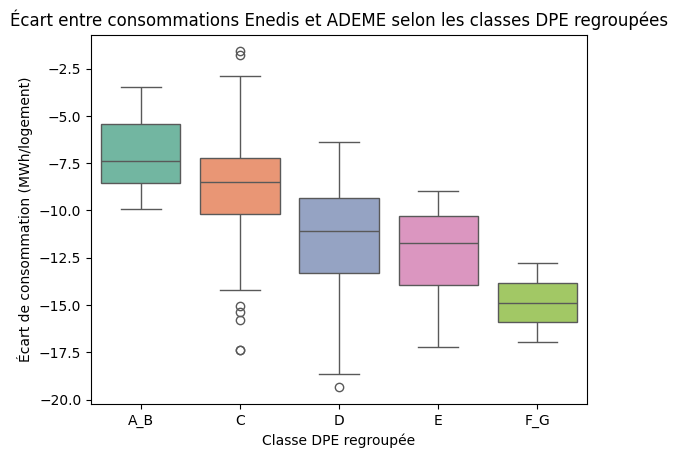

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_group,
    x="etiquette_dpe_grp",
    y="ecart_mwh",
    order=["A_B", "C", "D", "E", "F_G"], 
    palette="Set2"  
)

plt.title("Écart entre consommations Enedis et ADEME selon les classes DPE regroupées")
plt.xlabel("Classe DPE regroupée")
plt.ylabel("Écart de consommation (MWh/logement)")
plt.show()


#### **Interprétation :** Écart de consommation réelle (Enedis) vs estimée (ADEME)

Le graphique ci-dessus illustre la relation entre les **classes DPE regroupées** et l’**écart moyen de consommation énergétique** (en MWh/logement).  
Cet écart correspond à la différence entre la consommation réelle observée par **Enedis** et la consommation estimée par **ADEME**.

**Analyse :**
- **A_B (logements performants)** → Les écarts sont les plus faibles, proches de zéro.  
  ➜ Cela signifie que les estimations ADEME sont globalement cohérentes avec les consommations réelles.
- **C et D (classes intermédiaires)** → On observe une dispersion plus marquée.  
  ➜ Certains logements consomment plus que prévu, d’autres moins.
-  **E et F_G (logements énergivores)** → Les écarts deviennent fortement négatifs.  
  ➜ Les consommations réelles sont **supérieures aux estimations DPE**, indiquant une sous-évaluation de la consommation.

**Interprétation générale :**
Plus la classe DPE est mauvaise, **plus l’écart négatif augmente**.  
Autrement dit, **le DPE tend à sous-estimer la consommation réelle** des logements les moins performants.  

---


### 07. Exploration des variables explicatives

#### Variables numériques

In [97]:
order_dpe = ["A_B", "C", "D", "E", "F_G"]
df["etiquette_dpe_grp"] = pd.Categorical(df["etiquette_dpe_grp"], categories=order_dpe, ordered=True)

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




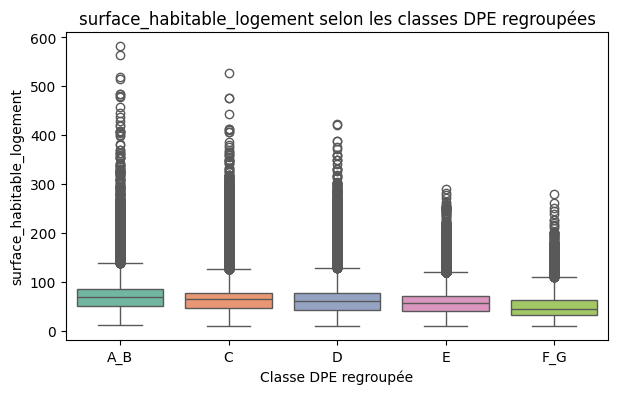

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




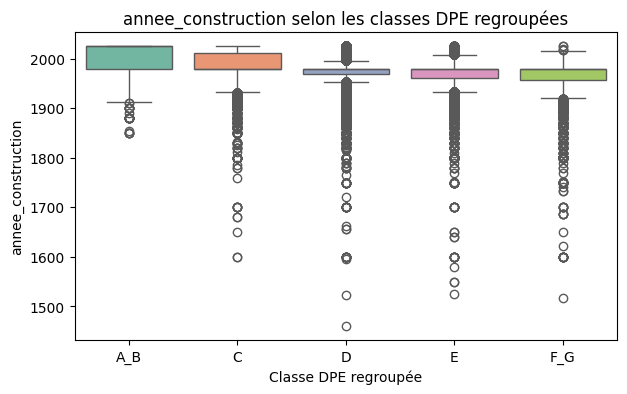

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




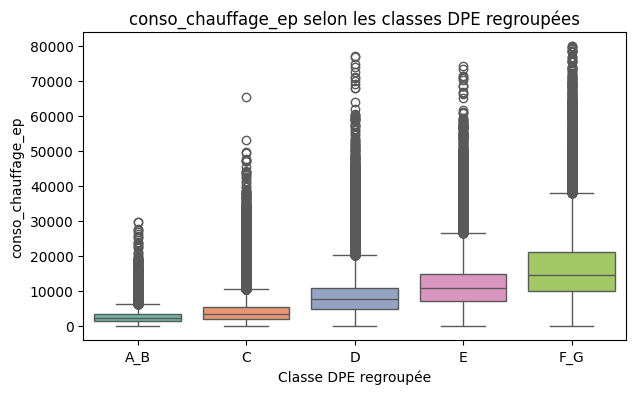

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




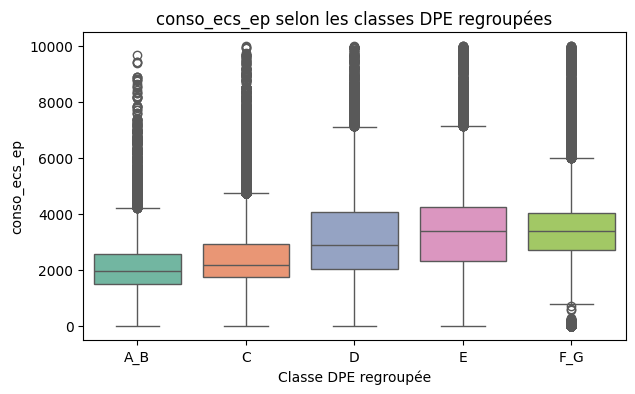

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




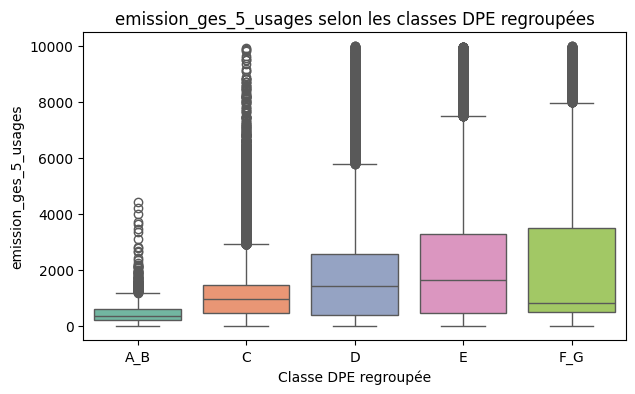

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




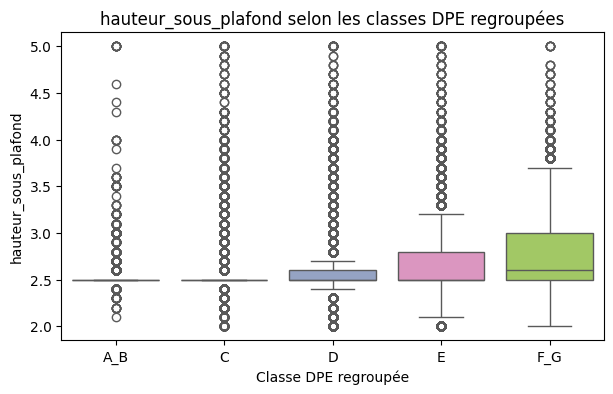

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




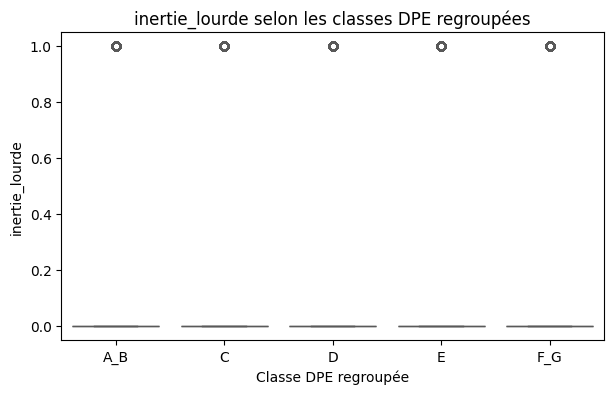

C:\Users\km_sa\AppData\Local\Temp\ipykernel_11872\443049517.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




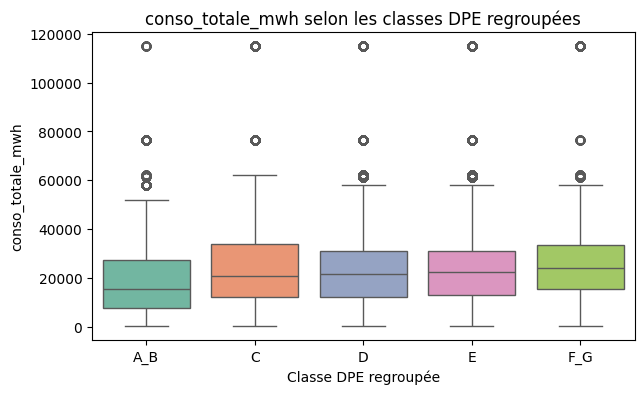

In [98]:
num_cols = [
    "surface_habitable_logement",
    "annee_construction",
    "conso_chauffage_ep",
    "conso_ecs_ep",
    "emission_ges_5_usages",
    "hauteur_sous_plafond",
    "inertie_lourde",
    "conso_totale_mwh"
]

for c in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x="etiquette_dpe_grp", y=c, order=order_dpe, palette="Set2")
    plt.title(f"{c} selon les classes DPE regroupées")
    plt.xlabel("Classe DPE regroupée")
    plt.ylabel(c)
    plt.show()

#### Variables numériques

| **Graphique** | **Interprétation brève** |
|----------------|---------------------------|
| `surface_habitable_logement` selon `etiquette_dpe_grp` | Les logements avec de meilleures classes DPE (A_B, C) ont en moyenne une surface légèrement plus grande, mais sans différence très marquée. La surface n’est pas le facteur principal du DPE. |
| `annee_construction` selon `etiquette_dpe_grp` | Les bâtiments récents (après 2000) sont majoritairement en classes A_B et C, alors que les bâtiments anciens (avant 1980) dominent dans E et F_G. → Forte influence de l’année de construction. |
| `conso_chauffage_ep` selon `etiquette_dpe_grp` | Les consommations de chauffage augmentent nettement des classes A_B → F_G. → Variable directement liée à la performance énergétique. |
| `conso_ecs_ep` selon `etiquette_dpe_grp` | La consommation d’eau chaude (ECS) suit une tendance similaire : plus élevée dans les classes F_G. → Influence secondaire mais cohérente. |
| `emission_ges_5_usages` selon `etiquette_dpe_grp` | Les émissions augmentent clairement avec les classes énergivores. → Confirme la cohérence physique entre GES et DPE. |
| `hauteur_sous_plafond` selon `etiquette_dpe_grp` | Les logements énergivores (F_G) ont légèrement plus de hauteurs sous plafond, donc plus de volume à chauffer. |
| `inertie_lourde` selon `etiquette_dpe_grp` | Très peu variable (quasi constante). → Faible pouvoir explicatif, peut être supprimée. |
| `conso_totale_mwh` selon `etiquette_dpe_grp` | Évolue logiquement avec la classe DPE, mais dépend du nombre de logements par IRIS. → Corrélée, donc à retirer. |


#### Variables catégorielles

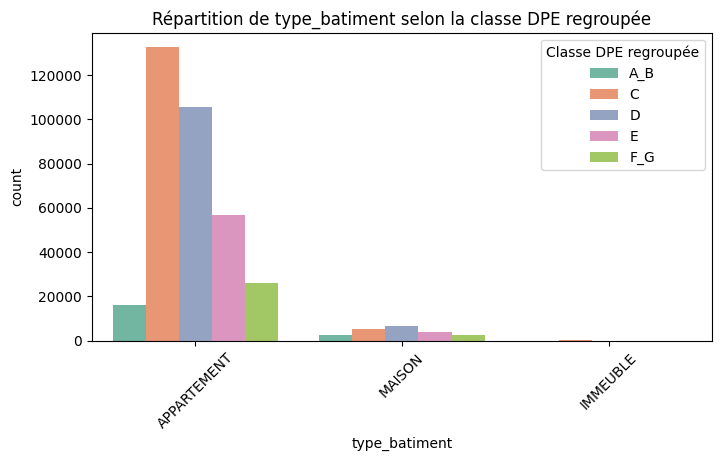

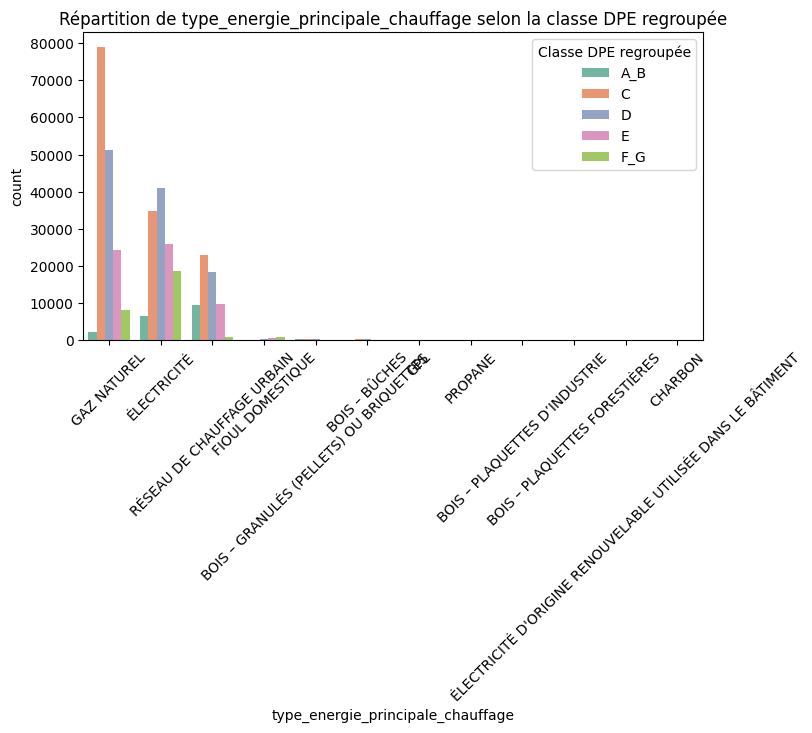

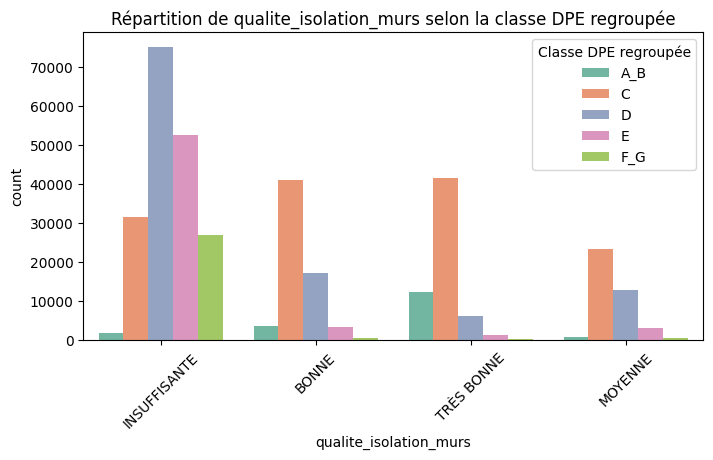

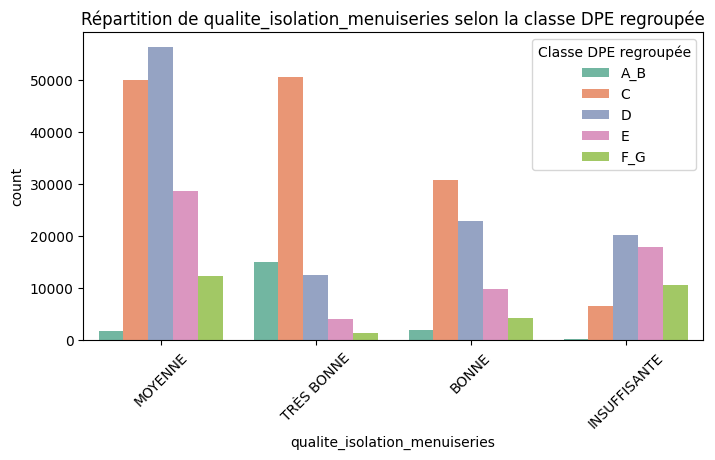

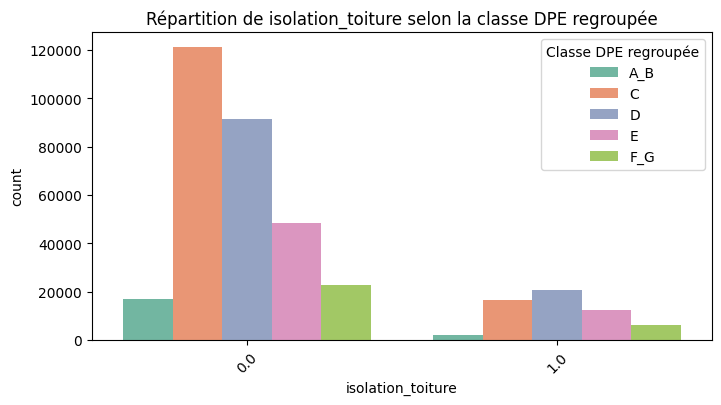

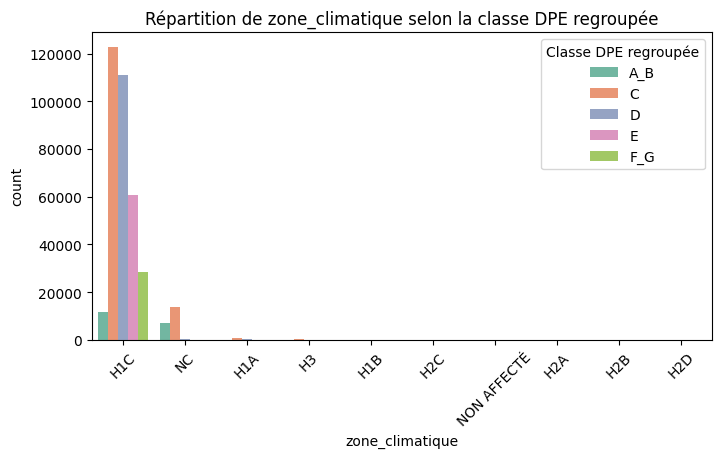

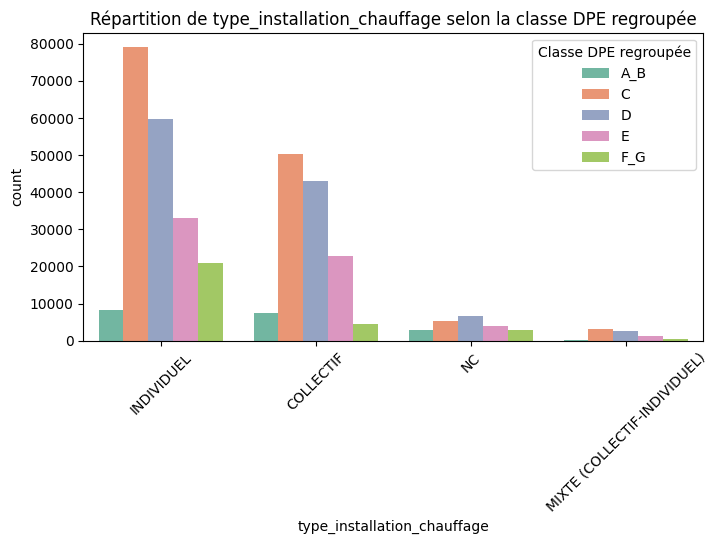

In [99]:
cat_cols = [
    "type_batiment",
    "type_energie_principale_chauffage",
    "qualite_isolation_murs",
    "qualite_isolation_menuiseries",
    "isolation_toiture",
    "zone_climatique",
    "type_installation_chauffage"
]

for c in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(
        data=df,
        x=c,
        hue="etiquette_dpe_grp",
        order=df[c].value_counts().index,
        hue_order=order_dpe,
        palette="Set2"
    )
    plt.title(f"Répartition de {c} selon la classe DPE regroupée")
    plt.xticks(rotation=45)
    plt.legend(title="Classe DPE regroupée", loc="upper right")
    plt.show()


#### Variables catégorielles

| **Graphique** | **Interprétation brève** |
|----------------|---------------------------|
| `type_batiment` | Les appartements dominent toutes les classes, mais les maisons sont plus fréquentes dans les classes énergivores (E, F_G). |
| `type_energie_principale_chauffage` | Le gaz naturel domine dans les classes moyennes (C/D), tandis que l’électricité et le fioul sont surreprésentés dans les classes F_G. |
| `qualite_isolation_murs` | Les classes A_B et C affichent des isolations “bonnes” à “très bonnes”, alors que E et F_G sont principalement “insuffisantes”. |
| `qualite_isolation_menuiseries` | Même tendance : meilleures menuiseries → meilleure classe DPE. |
| `isolation_toiture` | L’isolation toiture (valeur 1) est plus présente dans les classes performantes. → Variable pertinente. |
| `zone_climatique` | Majorité des logements en H1C, peu de variance. → Peu informative, à retirer. |
| `type_installation_chauffage` | Les installations collectives sont plus présentes dans les classes performantes (A_B, C). Les installations individuelles dominent les classes énergivores. |


#### Conclusion de l’exploration (EDA final)

##### Variables conservées pour la modélisation
- **Numériques** :  
  `surface_habitable_logement`, `annee_construction`, `conso_chauffage_ep`,  
  `conso_ecs_ep`, `emission_ges_5_usages`, `hauteur_sous_plafond`,  
  `conso_moy_site_mwh` (Enedis), `nombre_de_logements`.

- **Catégorielles** :  
  `type_batiment`, `type_energie_principale_chauffage`,  
  `qualite_isolation_murs`, `qualite_isolation_menuiseries`,  
  `isolation_toiture`, `type_installation_chauffage`.

##### Variables à créer
- `age_bat = 2025 - annee_construction`
- `chauf_intensite = conso_chauffage_ep / surface_habitable_logement`
- `ecs_intensite = conso_ecs_ep / surface_habitable_logement`
- `log_surface = log(surface_habitable_logement)`
- éventuellement : `bins_age` (catégorisation de `age_bat`)

##### Variables à écarter
- `inertie_lourde` (signal faible)
- `zone_climatique` (quasi constante → non discriminante)
- `conso_totale_mwh` (corrélée à nombre de logements)
- Coordonnées géographiques (`x`, `y`) et identifiants (`numero_dpe`, `codeiris`)

##### Les “fuites” potentielles
- Les variables `conso_5_usages_ep` et `emission_ges_5_usages`  
  entrent dans le calcul du DPE → elles peuvent biaiser la modélisation.  
  Deux scénarios seront donc testés :
  - **Modèle avec fuites** : meilleur score, mais moins généralisable.  
  - **Modèle sans fuites** : plus réaliste pour prédire un DPE inconnu.

